# Lab 5: Implementation of Ordinary Least Squares (OLS) and Gradient Descent for Linear Regression

**Course:** Machine Learning
**Lab:** 5
**Topic:** Implementation of Ordinary Least Squares (OLS) and Gradient Descent for Linear Regression

## Objective

- Implement simple linear regression from scratch in Python using two approaches:
  - **Analytical Approach:** Ordinary Least Squares (OLS) closed-form solution.
  - **Iterative Approach:** Batch Gradient Descent optimization.
- Train both implementations on a sample bivariate dataset (X = Height, y = Weight).
- Compare and verify the resulting parameters (m and c).
- Compute model evaluation metrics: Coefficient of Determination (R²), Standard Error, t-statistic, and the p-value for slope significance.
- Visualize the fitted regression lines against the ground truth data points.
- Analyze loss convergence behavior across iterations.

## Problem Statement & Dataset

Given the experimental dataset of Height ($X$) and Weight ($y$), find the best-fit line:

$$y = mx + c$$

| Observation (i) | Height (X) | Weight (y) |
|---|---|---|
| 1 | 0.5 | 1.4 |
| 2 | 2.3 | 1.9 |
| 3 | 2.9 | 3.2 |


## Task 1: Environment Setup

Import the required numerical, statistical, and plotting libraries: `numpy`, `matplotlib.pyplot`, and `scipy.stats`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =====================================================================
# Dataset Definition
# =====================================================================
X = np.array([0.5, 2.3, 2.9])
y = np.array([1.4, 1.9, 3.2])

print("X (Height):", X)
print("y (Weight):", y)


X (Height): [0.5 2.3 2.9]
y (Weight): [1.4 1.9 3.2]


## Task 2: Implement OLS Function

Complete `ols_linear_regression(X, y)`:

1. Compute mean values $\bar{x}$ and $\bar{y}$.
2. Compute the numerator and denominator using vectorized NumPy operations.
3. Return the calculated slope $m$ and intercept $c$.

$$m = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} \qquad c = \bar{y} - m\bar{x}$$

In [2]:
# =====================================================================
# TASK 1: Ordinary Least Squares (OLS) Implementation
# =====================================================================
def ols_linear_regression(X, y):
    """
    Compute linear regression parameters analytically using OLS closed-form formulas.

    Parameters:
    X (np.ndarray): Input feature vector (Height)
    y (np.ndarray): Target vector (Weight)

    Returns:
    m (float): Optimal slope
    c (float): Optimal intercept
    """
    # 1.1: Compute mean of X and mean of y
    x_mean = np.mean(X)
    y_mean = np.mean(y)

    # 1.2: Compute numerator and denominator for slope 'm'
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    m = numerator / denominator

    # 1.3: Compute intercept 'c'
    c = y_mean - m * x_mean

    return m, c


## Task 3: Implement Batch Gradient Descent

Complete `gradient_descent(X, y, alpha=0.05, epochs=1000)`:

1. Initialize $m=0.0$ and $c=0.0$.
2. For each epoch:
   - Compute predicted values $\hat{y} = mX + c$.
   - Compute and record the MSE loss.
   - Compute partial derivatives $\partial J/\partial m$ and $\partial J/\partial c$.
   - Update parameters $m$ and $c$ using learning rate $\alpha$.
3. Return the final parameters $m$, $c$, and the loss history array.

$$J(m,c) = \frac{1}{n}\sum_{i=1}^n (mx_i + c - y_i)^2 \qquad
\frac{\partial J}{\partial m} = \frac{2}{n}\sum_{i=1}^n (mx_i+c-y_i)\cdot x_i \qquad
\frac{\partial J}{\partial c} = \frac{2}{n}\sum_{i=1}^n (mx_i+c-y_i)$$

$$m := m - \alpha \cdot \frac{\partial J}{\partial m} \qquad c := c - \alpha \cdot \frac{\partial J}{\partial c}$$

In [3]:
# =====================================================================
# TASK 2: Batch Gradient Descent Implementation
# =====================================================================
def gradient_descent(X, y, alpha=0.05, epochs=1000):
    """
    Optimize linear regression parameters using batch gradient descent.

    Parameters:
    X (np.ndarray): Input feature vector
    y (np.ndarray): Target vector
    alpha (float): Learning rate
    epochs (int): Total training iterations

    Returns:
    m (float): Learned slope
    c (float): Learned intercept
    loss_history (list): MSE loss recorded per epoch
    """
    m = 0.0
    c = 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        # 2.1: Compute linear predictions (y_pred = m*X + c)
        y_pred = m * X + c

        # 2.2: Compute Mean Squared Error (MSE) loss and store in loss_history
        loss = np.mean((y_pred - y) ** 2)
        loss_history.append(loss)

        # 2.3: Compute partial derivatives dm and dc
        dm = (2 / n) * np.sum((y_pred - y) * X)
        dc = (2 / n) * np.sum(y_pred - y)

        # 2.4: Update parameters m and c using gradients and learning rate alpha
        m = m - alpha * dm
        c = c - alpha * dc

    return m, c, loss_history


## Task 4: Implement Statistical Evaluation Function (R² and p-value)

Complete `compute_evaluation_metrics(X, y, y_pred, m)`:

1. Compute $SS_{res}$ and $SS_{tot}$ to derive $R^2$.
2. Compute residual variance with $df = n-2$.
3. Compute the standard error $SE(m)$ and the corresponding t-statistic.
4. Calculate the two-tailed p-value using `scipy.stats.t.sf`.
5. Return $R^2$, t-statistic, and p-value.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} \qquad
SE(m) = \sqrt{\frac{s_e^2}{\sum_{i=1}^n (x_i-\bar{x})^2}} \qquad
t = \frac{m-0}{SE(m)} \qquad
p = 2\cdot(1-F(|t|,df))$$

In [4]:
# =====================================================================
# TASK 3: Model Evaluation Metrics (R2, t-statistic, and p-value)
# =====================================================================
def compute_evaluation_metrics(X, y, y_pred, m):
    """
    Calculate R-squared and statistical significance (p-value) of the slope parameter.

    Parameters:
    X (np.ndarray): Input feature vector
    y (np.ndarray): Target ground truth vector
    y_pred (np.ndarray): Predicted values from model
    m (float): Slope parameter

    Returns:
    r2 (float): Coefficient of determination
    t_stat (float): Student's t-statistic for slope
    p_val (float): Two-tailed p-value
    """
    n = len(X)
    df = n - 2

    # 3.1: Calculate SS_res (residual sum of squares) and SS_tot (total sum of squares)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    # 3.2: Calculate R-squared (R2)
    r2 = 1 - (ss_res / ss_tot)

    # 3.3: Calculate Standard Error of the slope SE(m)
    residual_variance = ss_res / df
    se_m = np.sqrt(residual_variance / np.sum((X - np.mean(X)) ** 2))

    # 3.4: Compute t-statistic (t = m / se_m)
    t_stat = m / se_m

    # 3.5: Compute two-tailed p-value using stats.t.sf
    p_val = 2 * stats.t.sf(np.abs(t_stat), df)

    return r2, t_stat, p_val


## Task 5: Model Execution & Evaluation Comparison

Run both methods on the dataset and print the fitted equations, $R^2$, t-statistic, and p-value side by side.

In [5]:
# =====================================================================
# TASK 4: Model Execution & Evaluation Comparison
# =====================================================================

# --- Execute OLS ---
m_ols, c_ols = ols_linear_regression(X, y)
y_pred_ols = m_ols * X + c_ols
r2_ols, t_ols, p_ols = compute_evaluation_metrics(X, y, y_pred_ols, m_ols)

print("===================== OLS RESULTS =====================")
print(f"Equation:    y = {m_ols:.4f}x + {c_ols:.4f}")
print(f"R-squared:   {r2_ols:.4f}")
print(f"t-statistic: {t_ols:.4f}")
print(f"p-value:     {p_ols:.4f}\n")

# --- Execute Gradient Descent ---
alpha = 0.05
epochs = 1500
m_gd, c_gd, losses = gradient_descent(X, y, alpha=alpha, epochs=epochs)
y_pred_gd = m_gd * X + c_gd
r2_gd, t_gd, p_gd = compute_evaluation_metrics(X, y, y_pred_gd, m_gd)

print("=============== GRADIENT DESCENT RESULTS ===============")
print(f"Equation:    y = {m_gd:.4f}x + {c_gd:.4f}")
print(f"R-squared:   {r2_gd:.4f}")
print(f"t-statistic: {t_gd:.4f}")
print(f"p-value:     {p_gd:.4f}\n")

print("=============== SIDE-BY-SIDE COMPARISON ===============")
print(f"{'Metric':<15}{'OLS':<15}{'Gradient Descent':<20}")
print(f"{'m (slope)':<15}{m_ols:<15.4f}{m_gd:<20.4f}")
print(f"{'c (intercept)':<15}{c_ols:<15.4f}{c_gd:<20.4f}")
print(f"{'R-squared':<15}{r2_ols:<15.4f}{r2_gd:<20.4f}")
print(f"{'t-statistic':<15}{t_ols:<15.4f}{t_gd:<20.4f}")
print(f"{'p-value':<15}{p_ols:<15.4f}{p_gd:<20.4f}")


===================== OLS RESULTS =====================
Equation:    y = 0.6410x + 0.9487
R-squared:   0.7425
t-statistic: 1.6981
p-value:     0.3388

=============== GRADIENT DESCENT RESULTS ===============
Equation:    y = 0.6410x + 0.9487
R-squared:   0.7425
t-statistic: 1.6981
p-value:     0.3388

=============== SIDE-BY-SIDE COMPARISON ===============
Metric         OLS            Gradient Descent    
m (slope)      0.6410         0.6410              
c (intercept)  0.9487         0.9487              
R-squared      0.7425         0.7425              
t-statistic    1.6981         1.6981              
p-value        0.3388         0.3388              


## Task 5: Visualization and Verification

- **Subplot 1:** Scatter plot of actual data points + Fitted OLS line + Fitted GD line.
- **Subplot 2:** Loss curve ($J$ vs Epochs) demonstrating convergence.

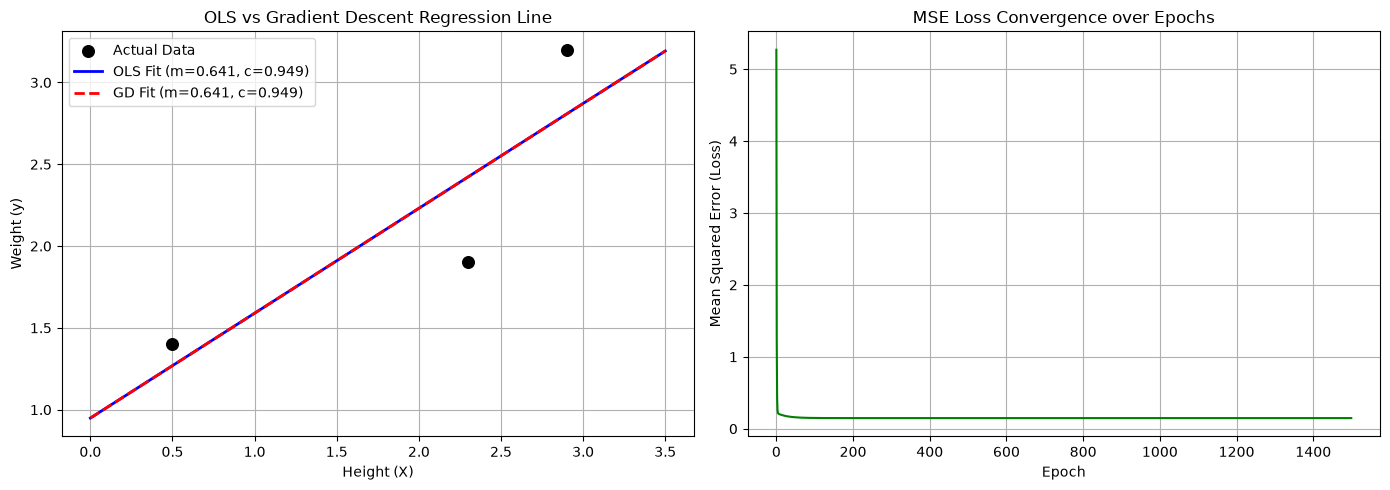

In [6]:
# =================================================================
# TASK 5: Plotting & Visualization
# =================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Regression Fit Comparison
# 5.1: Plot actual data points as scatter plot
axes[0].scatter(X, y, color='black', s=70, zorder=3, label='Actual Data')

# 5.2: Generate x_vals using np.linspace(0, 3.5, 100) and plot OLS & GD lines
x_vals = np.linspace(0, 3.5, 100)
axes[0].plot(x_vals, m_ols * x_vals + c_ols, color='blue', linewidth=2, label=f'OLS Fit (m={m_ols:.3f}, c={c_ols:.3f})')
axes[0].plot(x_vals, m_gd * x_vals + c_gd, color='red', linestyle='--', linewidth=2, label=f'GD Fit (m={m_gd:.3f}, c={c_gd:.3f})')

axes[0].set_title("OLS vs Gradient Descent Regression Line")
axes[0].set_xlabel("Height (X)")
axes[0].set_ylabel("Weight (y)")
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Loss Convergence Curve
# 5.3: Plot epoch index vs. loss_history
axes[1].plot(range(epochs), losses, color='green')
axes[1].set_title("MSE Loss Convergence over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Squared Error (Loss)")
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Bonus: Learning Rate Sensitivity Analysis

Exploring how different learning rates affect convergence (relevant to Viva Question 4).

d:\MachineLearningIET\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


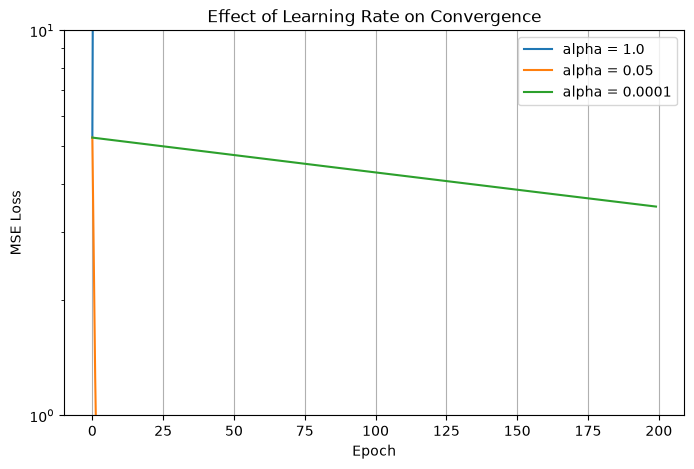

In [7]:
# Compare convergence behavior for different learning rates
learning_rates = [1.0, 0.05, 0.0001]
epochs_lr = 200

plt.figure(figsize=(8, 5))
with np.errstate(over='ignore', invalid='ignore'):
    for lr in learning_rates:
        _, _, loss_hist_lr = gradient_descent(X, y, alpha=lr, epochs=epochs_lr)
        plt.plot(range(epochs_lr), loss_hist_lr, label=f"alpha = {lr}")

plt.title("Effect of Learning Rate on Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()


## 6. Lab Report & Viva Questions

**1. Analytical vs. Iterative Comparison**

With enough epochs and a suitable learning rate, Gradient Descent's $(m, c)$ and $R^2$ converge to (very nearly) the same values as OLS, because both methods are minimizing the same convex MSE cost function, which has a single global minimum. Any slight difference is due to Gradient Descent being an *approximate, iterative* method — after a finite number of epochs it may not have fully converged to the exact minimum that the OLS closed-form solution reaches in one step.

**2. Interpreting R² vs. p-value for Small Sample Sizes (n = 3)**

For this dataset $R^2 \approx 0.74$ — a fairly strong fit — yet the p-value ($\approx 0.34$) is far above the $\alpha = 0.05$ significance threshold. With only $n=3$ points, $df = n-2 = 1$. $R^2$ only measures how much of the variance in $y$ is explained by the line — with just 3 points, a line can fit reasonably well "by chance," giving a moderate-to-high $R^2$, even if there's no real underlying relationship. The p-value, however, also accounts for the *uncertainty* in that estimate: with $df=1$, the standard error of the slope is large and the t-distribution has very fat tails, so it takes an extremely large t-statistic to reach significance. In other words, a high $R^2$ tells us the fit is tight for *this particular sample*, while the p-value tells us how confident we can be that the relationship isn't just a fluke of a tiny sample — and with so few data points, that confidence is inherently low.

**3. Hypothesis Testing**

- $H_0$: $m = 0$ — there is no linear relationship between Height and Weight.
- $H_1$: $m \neq 0$ — there is a statistically significant linear relationship between Height and Weight.

**4. Learning Rate Sensitivity**

- $\alpha = 1.0$ (too large): The updates overshoot the minimum at every step. The loss can oscillate wildly or diverge (grow towards infinity) instead of decreasing, since each step overcorrects past the optimal point.
- $\alpha = 0.0001$ (too small): The updates are extremely tiny, so the parameters move toward the minimum very slowly. The loss decreases, but convergence within a fixed number of epochs may be far from complete (the model appears to "barely learn" anything).

**5. Computational Scalability**

The OLS closed-form solution requires computing $(X^TX)^{-1}$, a matrix inversion that costs roughly $O(d^3)$ for $d$ features (and also requires forming $X^TX$, an $O(nd^2)$ operation). For datasets with millions of features and/or samples, this becomes computationally infeasible in both time and memory — the matrix may not even be invertible (singular) if features are collinear or $n < d$. Gradient Descent instead only requires computing gradients via matrix-vector products, roughly $O(nd)$ per iteration, which scales far better, can be run in mini-batches that don't require the full dataset in memory at once, and works even when a closed-form matrix inverse doesn't exist or is too expensive to compute.